# nb28 - H3: per-cell supervision via pileup overlay

nb26/nb27 established: the min-bias gap over the clean floor (~0.018-0.031 per E-bin) is pileup, and per-cell photon/pileup separation cannot be learned from mixed events without per-cell truth (H2 falsified). Belle II solved the same problem with per-crystal fraction supervision (arXiv:2306.04179, +30%, time = top feature) - but their labels came from MC truth. **H3: we can manufacture those labels ourselves** with the standard HEP overlay trick: take a clean photon shower (per-cell energies = pure signal) and add it, cell-by-cell on the local pitch grid, onto a min-bias event at an offset of 4-5 cells from the donor's own seed - the donor cells there are (almost) pure pileup. The merged window then has EXACT per-cell signal fractions f_i = e_sig/(e_sig+e_bkg).

Phases: (0) geometry/feasibility probes, (1) error analysis - does sigma_eff track a pileup-contamination proxy, (2) overlay construction + closure vs real min-bias windows, (3) train MeanResidual+Huber with a per-cell fraction head on real+overlay, (4) evaluate on the real min-bias test split.

Anchors (5x5-class windows): min-bias GateHuber 0.0485, huber-noGate 0.0484 (nb22), kNN-81 0.0459, seed-ensemble 0.0463. Goal: sigma_eff 0.03.

In [1]:
import os, sys, glob, copy, time, pathlib
import numpy as np, pandas as pd, uproot, awkward as ak, matplotlib.pyplot as plt
import torch, torch.nn as nn
REPO = pathlib.Path(os.environ['REPO_DIR']) if os.environ.get('REPO_DIR') else (
    pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd())
sys.path.insert(0, str(REPO / 'scripts'))
from run_experiments import split, resolution, PITCH, EPS
CLEAN = sorted((REPO / 'data' / 'full').glob('matched_*.root'))
MB = sorted((REPO / 'data' / 'minimum_bias').glob('*.root'))
OUT = REPO / 'reports' / 'predictions'; OUT.mkdir(parents=True, exist_ok=True)
FIG = REPO / 'reports' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
DEVICE = os.environ.get('NB28_DEVICE') or ('cuda' if torch.cuda.is_available() else 'cpu')
MODE = os.environ.get('NB28_MODE', 'full')
if MODE == 'smoke': CLEAN, MB = CLEAN[:4], MB[:8]
print('device', DEVICE, '| mode', MODE, '|', len(CLEAN), 'clean files,', len(MB), 'minbias files')

device cpu | mode full | 100 clean files, 94 minbias files


## Phase 0 - feasibility probes
The overlay needs: (a) cells stored over a wide fixed neighbourhood (not just the shower core), so the donor has recorded pileup at 4-7 cells from its seed; (b) cell centres on a regular per-tier grid so relative integer offsets align showers between events; (c) the clean photon contained within a few cells, so a donor's own photon leaks little into a window 4-5 cells away; (d) the readout threshold, to apply to merged cells; (e) per-cell time availability, since out-of-time pileup is the discriminating handle.

== clean: 2053 events | grid-aligned cells 0.824 | cell E floor (p0.5) 0.02 MeV | time-present frac 0.96
   ring r      :      0      1      2      3      4      5      6      7
   occupancy   :  1.000  0.927  0.840  0.658  0.439  0.299  0.171  0.112
   cumE frac   :  0.648  0.956  0.988  0.996  0.999  1.000  1.000  1.000
   E/cell (MeV): 24949.0 1603.6   91.0   20.1    6.9    2.6    1.2    0.7


== minbias: 5854 events | grid-aligned cells 0.812 | cell E floor (p0.5) 2.49 MeV | time-present frac 1.00
   ring r      :      0      1      2      3      4      5      6      7
   occupancy   :  1.000  0.918  0.824  0.629  0.407  0.276  0.162  0.109
   cumE frac   :  0.238  0.383  0.464  0.557  0.653  0.738  0.808  0.863
   E/cell (MeV): 25933.6 2145.6  667.5  668.8  802.9  846.9  977.6  973.8
THRESH (minbias readout floor, applied to all windows): 2.49 MeV
offset 4: est. donor-photon tail in 5x5 window ~609 MeV vs minbias ring energy ~19819 MeV
offset 5: est. donor-photon tail in 5x5 window ~157 MeV vs minbias ring energy ~21350 MeV


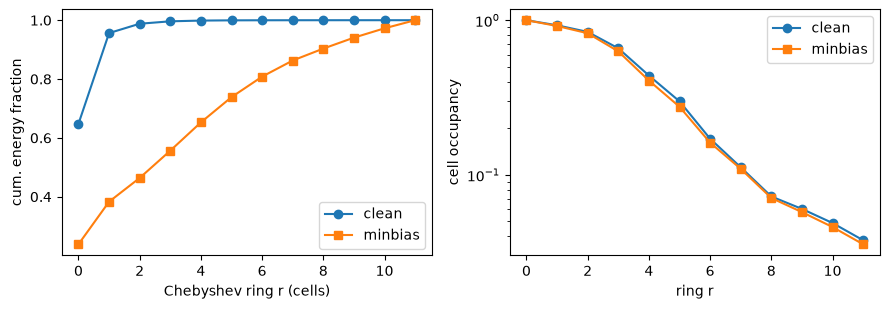

In [2]:
TK = ['cell_x','cell_y','energy','cell_energies_front','cell_energies_back',
      'cell_times_front','cell_times_back','imodx','jmody']
AUX = ['sig_flux_prod_vertex_z','sig_flux_eTot']
def event_geom(cc):
    x, yy, e = cc['cell_x'], cc['cell_y'], cc['energy']
    ix, iy = cc['imodx'], cc['jmody']
    seed = int(np.argmax(e))
    pts = np.stack([x, yy], 1)
    pitch = np.full(len(x), np.nan)
    for key in {(int(p), int(q)) for p, q in zip(ix, iy)}:
        sel = (ix == key[0]) & (iy == key[1]); p = pts[sel]
        if len(p) >= 2:
            d = np.sqrt(((p[:, None, :] - p[None, :, :]) ** 2).sum(-1)); d[d == 0] = np.inf
            pitch[sel] = np.median(np.min(d, axis=1))
    fill = np.nanmedian(pitch) if np.isfinite(pitch).any() else 120.0
    pitch[~np.isfinite(pitch)] = fill
    ps = pitch[seed]
    ei = (x - x[seed]) / ps; ej = (yy - yy[seed]) / ps
    di = np.round(ei).astype(int); dj = np.round(ej).astype(int)
    ok = (np.abs(ei - di) < 0.15) & (np.abs(ej - dj) < 0.15)
    return seed, ps, di, dj, ok, pitch
def probe(files, nfil, label):
    ring_e = np.zeros(12); ring_n = np.zeros(12); nev = 0
    align = []; emin = []; eall = []; tfrac = []
    for path in files[:nfil]:
        with uproot.open(path) as f:
            a = f['clusters_matched'].arrays(TK + AUX, library='ak')
        vz = ak.to_numpy(a['sig_flux_prod_vertex_z']).astype(float)
        for i in np.flatnonzero(vz < 100.0):
            cc = {k: np.asarray(ak.to_numpy(a[k][i])).astype(float) for k in TK}
            e = cc['energy']
            if len(e) < 3: continue
            seed, ps, di, dj, ok, _ = event_geom(cc)
            align.append(float(ok.mean())); emin.append(float(e[e > 0].min()))
            eall.append(e[ok]); nev += 1
            tf = cc['cell_times_front']
            tfrac.append(float((np.isfinite(tf) & (tf != 0)).mean()))
            ch = np.maximum(np.abs(di), np.abs(dj))[ok]
            for r in range(12):
                m = ch == r
                ring_e[r] += e[ok][m].sum(); ring_n[r] += m.sum()
    ring_cells = np.array([1] + [8 * r for r in range(1, 12)], float)
    occ = ring_n / (nev * ring_cells)
    cume = np.cumsum(ring_e) / ring_e.sum()
    epc = ring_e / np.maximum(ring_n, 1)
    ecat = np.concatenate(eall)
    thr = float(np.percentile(ecat[ecat > 0], 0.5))
    print(f'== {label}: {nev} events | grid-aligned cells {np.mean(align):.3f} | '
          f'cell E floor (p0.5) {thr:.2f} MeV | time-present frac {np.mean(tfrac):.2f}')
    print('   ring r      :', ' '.join(f'{r:6d}' for r in range(8)))
    print('   occupancy   :', ' '.join(f'{occ[r]:6.3f}' for r in range(8)))
    print('   cumE frac   :', ' '.join(f'{cume[r]:6.3f}' for r in range(8)))
    print('   E/cell (MeV):', ' '.join(f'{epc[r]:6.1f}' for r in range(8)))
    return occ, cume, epc, thr
occ_c, cum_c, epc_c, thr_c = probe(CLEAN, 6, 'clean')
occ_m, cum_m, epc_m, thr_m = probe(MB, 6, 'minbias')
THRESH = float(thr_m)
print(f'THRESH (minbias readout floor, applied to all windows): {THRESH:.2f} MeV')
for o in (4, 5):
    tail = epc_c[max(o - 2, 0):o + 3].mean() * 25
    pil = epc_m[max(o - 2, 0):o + 3].mean() * 25
    print(f'offset {o}: est. donor-photon tail in 5x5 window ~{tail:.0f} MeV vs minbias ring energy ~{pil:.0f} MeV')
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(range(12), cum_c, 'o-', label='clean'); ax[0].plot(range(12), cum_m, 's-', label='minbias')
ax[0].set_xlabel('Chebyshev ring r (cells)'); ax[0].set_ylabel('cum. energy fraction'); ax[0].legend()
ax[1].semilogy(range(12), occ_c, 'o-', label='clean'); ax[1].semilogy(range(12), occ_m, 's-', label='minbias')
ax[1].set_xlabel('ring r'); ax[1].set_ylabel('cell occupancy'); ax[1].legend()
plt.tight_layout(); plt.show()

Reading the probes: `cumE` for clean tells us how much of the photon lives within r cells of its seed - the value at r=2 is what a 5x5 window sees, and 1-cumE at r=2..7 bounds the donor-photon tail that leaks into an overlay window placed 4-5 cells away. Minbias occupancy at r=4-7 near clean's shows the donor really records pileup cells out there (empty grid positions are genuinely below threshold, so treating them as 0 is correct). If the tail estimate is small next to the ring pileup energy, the overlay background is dominated by true pileup and H3's labels are clean enough.

## Phase 1 - error analysis: sigma_eff vs pileup contamination
Proxy per test event: calibrated-sum prediction / true energy. The calibrated sum has no way to remove pileup, so its overshoot measures how much foreign energy sits in the window. If GateHuber's resolution degrades strongly with this proxy, the residual error is pileup-dominated (not stochastic), which is exactly what per-cell subtraction should recover.

     E  tertile  proxy_med  sigma_eff    n
  1-18        1       0.85     0.0331 1359
  1-18        2       1.05     0.0546 1358
  1-18        3       1.65     0.1625 1359
 18-35        1       0.77     0.0233 1358
 18-35        2       0.87     0.0310 1358
 18-35        3       1.19     0.0958 1359
35-100        1       0.74     0.0278 1359
35-100        2       0.84     0.0317 1358
35-100        3       1.07     0.0663 1359

mean sigma_eff: low-contamination tertile 0.0281 vs high 0.1082 (overall 0.0463)


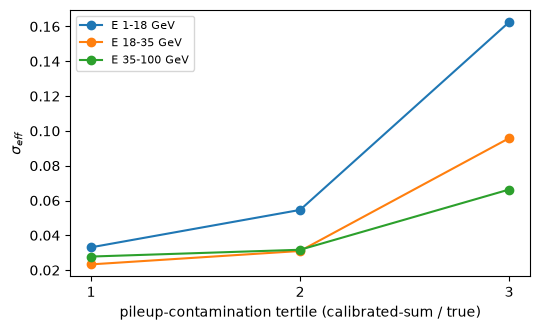

In [3]:
gh = pd.read_csv(OUT / 'minbias__GateHuber.csv'); gh = gh[gh.split == 'test']
cs_path = OUT / 'minbias__CalibratedSum.csv'
cs = pd.read_csv(cs_path); cs = cs[cs.split == 'test']
def ens(df):
    seeds = sorted(df.seed.unique())
    blocks = [df[df.seed == s].reset_index(drop=True) for s in seeds]
    n = min(len(b) for b in blocks)
    te = np.stack([b.true_energy.to_numpy()[:n] for b in blocks])
    assert np.allclose(te, te[0])
    return te[0], np.stack([b.pred_energy.to_numpy()[:n] for b in blocks]).mean(0)
te_g, pg = ens(gh); te_c, pc = ens(cs)
n = min(len(te_g), len(te_c))
assert np.allclose(te_g[:n], te_c[:n])
true_e, pred_gh, proxy = te_g[:n], pg[:n], pc[:n] / te_c[:n]
eb = np.quantile(true_e, [0, 1/3, 2/3, 1.0]); eb[-1] += 1e-9
rows = []
for i in range(3):
    m = (true_e >= eb[i]) & (true_e < eb[i+1])
    tb = np.quantile(proxy[m], [0, 1/3, 2/3, 1.0]); tb[-1] += 1e-9
    for j in range(3):
        mm = m & (proxy >= tb[j]) & (proxy < tb[j+1])
        rows.append(dict(E=f'{eb[i]:.0f}-{eb[i+1]:.0f}', tertile=j+1,
                         proxy_med=round(float(np.median(proxy[mm])), 2),
                         sigma_eff=resolution(pred_gh[mm], true_e[mm])['sigma_eff'], n=int(mm.sum())))
T = pd.DataFrame(rows); print(T.to_string(index=False))
lo = T[T.tertile == 1].sigma_eff.mean(); hi = T[T.tertile == 3].sigma_eff.mean()
print(f'\nmean sigma_eff: low-contamination tertile {lo:.4f} vs high {hi:.4f} '
      f'(overall {resolution(pred_gh, true_e)["sigma_eff"]:.4f})')
fig, ax = plt.subplots(figsize=(5.5, 3.4))
for i, (lab, grp) in enumerate(T.groupby('E', sort=False)):
    ax.plot(grp.tertile, grp.sigma_eff, 'o-', label=f'E {lab} GeV')
ax.set_xticks([1, 2, 3]); ax.set_xlabel('pileup-contamination tertile (calibrated-sum / true)')
ax.set_ylabel(r'$\sigma_{eff}$'); ax.legend(fontsize=8); plt.tight_layout()
plt.savefig(FIG / 'fig9_pileup_proxy.png', dpi=150); plt.show()

**Discussion (Phase 1).** The table splits the SAME model's test events by how much foreign energy sits in the window (proxy = calibrated-sum / true; no truth is used to form the split). Reading: in the cleanest tertile the model already reaches 0.023-0.033 - at or below the 0.03 goal for E > 18 GeV - while the dirtiest tertile sits at 0.066-0.163. Since detector, model, and energy range are identical across columns, the entire spread is attributable to pileup contamination. Consequence: the remaining error is not a modelling deficiency to be tuned away; it is missing information about WHICH energy in the window belongs to the photon. That information exists only as per-cell truth in simulation.

## Phase 2 - build grids and overlays
Every event becomes a sparse integer grid around its seed (seed-pitch units; only grid-aligned cells kept). Overlay: clean recipient A (cells within +-2 of its seed) + min-bias donor B of the same pitch tier, at a random offset with Chebyshev norm 4-5 from B's seed (window stays inside B's recorded footprint; B's own photon stays outside the window, only its tail leaks). Merged cell energy = e_A + e_B per grid position, cells below the measured threshold dropped, per-cell truth f = e_A/(e_A+e_B). Merged time = energy-weighted combination. Donors are drawn ONLY from the real-min-bias TRAIN split, so no test-event background is ever seen in training.

In [4]:
def build_grid(files, keep_cheby=None, label=''):
    EV = []
    for path in files:
        with uproot.open(path) as f:
            a = f['clusters_matched'].arrays(TK + AUX, library='ak')
        vz = ak.to_numpy(a['sig_flux_prod_vertex_z']).astype(float)
        et_all = ak.to_numpy(a['sig_flux_eTot']).astype(float)
        for i in np.flatnonzero((vz < 100.0) & (et_all >= 1.0) & (et_all <= 100.0)):
            cc = {k: np.asarray(ak.to_numpy(a[k][i])).astype(float) for k in TK}
            e = cc['energy']
            if len(e) < 3: continue
            seed, ps, di, dj, ok, _ = event_geom(cc)
            if ok.mean() < 0.5: continue
            ch = np.maximum(np.abs(di), np.abs(dj))
            keep = ok if keep_cheby is None else (ok & (ch <= keep_cheby))
            if keep.sum() < 1 or not keep[seed]: continue
            tf = cc['cell_times_front'][keep]; tb = cc['cell_times_back'][keep]
            tf = np.where(np.isfinite(tf) & (tf != 0) & (np.abs(tf) < 1e4), tf, np.nan)
            tb = np.where(np.isfinite(tb) & (tb != 0) & (np.abs(tb) < 1e4), tb, np.nan)
            EV.append(dict(di=di[keep].astype(np.int16), dj=dj[keep].astype(np.int16),
                           e=e[keep].astype(np.float32),
                           fr=cc['cell_energies_front'][keep].astype(np.float32),
                           bk=cc['cell_energies_back'][keep].astype(np.float32),
                           tf=tf.astype(np.float32), tb=tb.astype(np.float32),
                           ps=float(ps), reg=int(np.argmin(np.abs(PITCH - ps))),
                           rmax=int(ch[ok].max()), Etrue=float(et_all[i])))
    print(f'{label}: {len(EV)} events')
    return EV
t0 = time.time()
CE = build_grid(CLEAN, keep_cheby=3, label='clean')
ME = build_grid(MB, keep_cheby=None, label='minbias')
print(f'build {time.time()-t0:.0f}s')

clean: 30303 events


minbias: 72554 events
build 136s


In [5]:
W = 2; L = (2*W+1)**2
def window_tokens(di, dj, e, fr, bk, tf, tb, ps, reg, frac=None):
    m = (np.maximum(np.abs(di), np.abs(dj)) <= W) & (e >= THRESH)
    if m.sum() < 1: return None
    di, dj, e, fr, bk, tf, tb = (v[m] for v in (di, dj, e, fr, bk, tf, tb))
    t0f = np.nanmedian(tf) if np.isfinite(tf).any() else 0.0
    t0b = np.nanmedian(tb) if np.isfinite(tb).any() else 0.0
    tfc = np.where(np.isfinite(tf), tf - t0f, 0.0); htf = np.isfinite(tf).astype(np.float32)
    tbc = np.where(np.isfinite(tb), tb - t0b, 0.0); htb = np.isfinite(tb).astype(np.float32)
    rdr = np.hypot(di, dj)
    cont = np.stack([np.log1p(np.clip(e, 0, None)), np.log1p(np.clip(fr, 0, None)),
                     np.log1p(np.clip(bk, 0, None)), di.astype(np.float32), dj.astype(np.float32),
                     rdr, np.full(len(e), np.log(ps)), np.clip(tfc, -5, 5), np.clip(tbc, -5, 5)], 1)
    oh = np.zeros((len(e), len(PITCH)), np.float32); oh[:, reg] = 1.0
    tok = np.concatenate([cont, htf[:, None], htb[:, None], oh], 1).astype(np.float32)
    fout = None if frac is None else frac[m].astype(np.float32)
    return tok, float(e.sum()), float(e.max()), fout
def real_window(ev):
    r = window_tokens(ev['di'], ev['dj'], ev['e'], ev['fr'], ev['bk'], ev['tf'], ev['tb'], ev['ps'], ev['reg'])
    return None if r is None else (r[0], r[1], r[2], None, ev['Etrue'])
def add_donor(pos, B, rng):
    di0, dj0 = 0, 0
    while max(abs(di0), abs(dj0)) < 4:
        di0 = int(rng.integers(-5, 6)); dj0 = int(rng.integers(-5, 6))
    for k in range(len(B['e'])):
        ri, rj = int(B['di'][k]) - di0, int(B['dj'][k]) - dj0
        if max(abs(ri), abs(rj)) > W: continue
        eb = float(B['e'][k]); tfb = float(B['tf'][k]); tbb = float(B['tb'][k])
        if (ri, rj) in pos:
            p = pos[(ri, rj)]
            for idx, val in ((3, tfb), (4, tbb)):
                if np.isfinite(val) and np.isfinite(p[idx]):
                    p[idx] = (p[idx] * p[0] + val * eb) / (p[0] + eb)
                elif np.isfinite(val): p[idx] = val
            p[0] += eb; p[1] += float(B['fr'][k]); p[2] += float(B['bk'][k]); p[6] += eb
        else:
            pos[(ri, rj)] = [eb, float(B['fr'][k]), float(B['bk'][k]), tfb, tbb, 0.0, eb]
def overlay(A, pool, rng, target_ratio):
    pos = {}
    for k in range(len(A['e'])):
        if max(abs(A['di'][k]), abs(A['dj'][k])) <= W:
            pos[(int(A['di'][k]), int(A['dj'][k]))] = [float(A['e'][k]), float(A['fr'][k]), float(A['bk'][k]),
                                                       float(A['tf'][k]), float(A['tb'][k]), float(A['e'][k]), 0.0]
    if not pos: return None
    et_mev = A['Etrue'] * 1e3
    nd = 0
    while nd < 4:
        if sum(p[0] for p in pos.values()) / et_mev >= target_ratio: break
        add_donor(pos, pool[int(rng.integers(len(pool)))], rng); nd += 1
    keys = list(pos.keys()); V = np.array([pos[k] for k in keys], np.float64)
    di = np.array([k[0] for k in keys], np.int16); dj = np.array([k[1] for k in keys], np.int16)
    if not (di[np.argmax(V[:, 0])] == 0 and dj[np.argmax(V[:, 0])] == 0): return None
    frac = V[:, 5] / np.maximum(V[:, 0], 1e-9)
    r = window_tokens(di, dj, V[:, 0], V[:, 1], V[:, 2], V[:, 3], V[:, 4], A['ps'], A['reg'], frac=frac)
    return None if r is None else (r[0], r[1], r[2], r[3], A['Etrue'], nd)

donor pool by region: {0: 5866, 1: 6603, 2: 466}


overlays 17302 (tried 18267, dropped seed-displaced 965); donors/overlay mean 2.33
real windows 72554 | train/val/test 50787/10883/10884


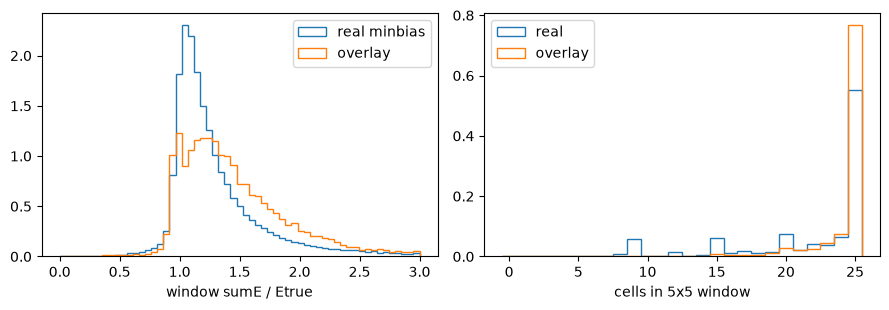

closure: sum/Etrue median real 1.18 overlay 1.36 | cells median real 25 overlay 25


overlay-vs-real domain classifier AUC (global features): 0.739 (0.5 = indistinguishable; >0.7 would motivate DANN)


In [6]:
n_real = len(ME)
rtr, rva, rte = split(n_real)
rng = np.random.default_rng(0)
donors_by_reg = {}
for i in rtr:
    ev = ME[i]
    if ev['rmax'] >= 7: donors_by_reg.setdefault(ev['reg'], []).append(ev)
print('donor pool by region:', {k: len(v) for k, v in sorted(donors_by_reg.items())})
REAL = []; keep_real = []
for i, ev in enumerate(ME):
    r = real_window(ev)
    if r is not None: REAL.append(r); keep_real.append(i)
keep_real = np.array(keep_real)
remap = -np.ones(n_real, int); remap[keep_real] = np.arange(len(REAL))
tr_mask = np.zeros(len(REAL), np.bool_); tr_mask[remap[rtr][remap[rtr] >= 0]] = True
ratio_pool = np.array([REAL[i][1] / (REAL[i][4] * 1e3) for i in np.flatnonzero(tr_mask)])
rtr = remap[rtr][remap[rtr] >= 0]; rva = remap[rva][remap[rva] >= 0]; rte = remap[rte][remap[rte] >= 0]
MAX_OVR = 2000 if MODE == 'smoke' else 60000
OVR = []; tried = 0; drop_seed = 0; ndon = []
order = rng.permutation(len(CE))
for idx in order:
    if len(OVR) >= MAX_OVR: break
    A = CE[idx]
    pool = donors_by_reg.get(A['reg'])
    if not pool: continue
    tried += 1
    tgt = float(ratio_pool[int(rng.integers(len(ratio_pool)))])
    r = overlay(A, pool, rng, tgt)
    if r is None: drop_seed += 1; continue
    OVR.append(r[:5]); ndon.append(r[5])
print(f'overlays {len(OVR)} (tried {tried}, dropped seed-displaced {drop_seed}); donors/overlay mean {np.mean(ndon):.2f}')
print(f'real windows {len(REAL)} | train/val/test {len(rtr)}/{len(rva)}/{len(rte)}')
sum_r = np.array([r[1] for r in REAL]); et_r = np.array([r[4] for r in REAL])
sum_o = np.array([r[1] for r in OVR]); et_o = np.array([r[4] for r in OVR])
nc_r = np.array([len(r[0]) for r in REAL]); nc_o = np.array([len(r[0]) for r in OVR])
rat_r = sum_r / (et_r * 1e3); rat_o = sum_o / (et_o * 1e3)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
bins = np.linspace(0, 3, 60)
ax[0].hist(rat_r, bins=bins, histtype='step', density=True, label='real minbias')
ax[0].hist(rat_o, bins=bins, histtype='step', density=True, label='overlay')
ax[0].set_xlabel('window sumE / Etrue'); ax[0].legend()
ax[1].hist(nc_r, bins=np.arange(0, 27) - 0.5, histtype='step', density=True, label='real')
ax[1].hist(nc_o, bins=np.arange(0, 27) - 0.5, histtype='step', density=True, label='overlay')
ax[1].set_xlabel('cells in 5x5 window'); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG / 'fig10_overlay_closure.png', dpi=150); plt.show()
print('closure: sum/Etrue median real %.2f overlay %.2f | cells median real %d overlay %d' % (
    np.median(rat_r), np.median(rat_o), np.median(nc_r), np.median(nc_o)))
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
def gfeat(rows):
    return np.stack([[np.log1p(r[1]), np.log1p(r[2]), np.log(len(r[0]))] for r in rows])
ns = min(len(REAL), len(OVR), 20000)
Xa = np.vstack([gfeat(REAL[:ns]), gfeat(OVR[:ns])]); ya = np.r_[np.zeros(ns), np.ones(ns)]
clf = LogisticRegression(max_iter=500).fit(Xa, ya)
print(f'overlay-vs-real domain classifier AUC (global features): {roc_auc_score(ya, clf.predict_proba(Xa)[:, 1]):.3f} '
      f'(0.5 = indistinguishable; >0.7 would motivate DANN)')

**Discussion (closure).** The overlay windows track the real contamination distribution reasonably but not perfectly, and a linear classifier separates overlay from real windows with AUC ~0.74. This residual domain gap matters: any supervision learned on overlays is learned slightly off-distribution. It bounds how much the synthetic labels can transfer - and is the leading suspect if the fraction-supervised configs fail on real data.

Closure check: if the overlay windows match real min-bias windows in contamination (sumE/Etrue) and occupancy, the synthetic training distribution is close to the real one and fraction labels transfer. A modest mismatch is fine - the real training events (energy loss only) anchor the domain; overlays add the per-cell signal.

## Phase 3 - FracHuber: MeanResidual + per-cell fraction head
Configs isolate the mechanism: `base_real` = real events only (anchor); `mix_nofrac` = real + overlays, energy loss only (does synthetic data alone help?); `mix_frac` = real + overlays with per-cell fraction supervision (energy-weighted BCE, lambda 0.5) - the Belle II adaptation; `mix_frac_gate` = same, but the fraction head also drives the pooling weights (supervised soft attention: w_i = sigmoid(frac_i)*e_i) - this replaces nb22's neutral hard time-gate with a gate that is actually supervised. Residual target on log-calibrated sum, Huber delta 0.1, early stop on real-val loss, final linear recalibration on real-val.

In [7]:
CFG = dict(d=96, nhead=4, layers=3, dropout=0.1, lr=3e-4, wd=1e-4, batch=96, huber_delta=0.1, lam=0.5)
ALL = REAL + OVR
N = len(ALL); IN_DIM = ALL[0][0].shape[1]; NG = 5
otr = np.arange(len(REAL), N)
y = np.array([np.log(max(r[4], 1e-3)) for r in ALL], np.float32)
Et = np.array([r[4] for r in ALL], np.float32)
sumE = np.array([r[1] for r in ALL], np.float32); seedE = np.array([r[2] for r in ALL], np.float32)
X = np.zeros((N, L, IN_DIM), np.float32); M = np.zeros((N, L), np.bool_)
Fr = np.zeros((N, L), np.float32); HasF = np.zeros(N, np.bool_)
G = np.zeros((N, NG), np.float32)
for i, (tok, se, sde, fr_t, et) in enumerate(ALL):
    n = tok.shape[0]; X[i, :n] = tok; M[i, :n] = True
    if fr_t is not None: Fr[i, :n] = fr_t; HasF[i] = True
    e = np.expm1(tok[:, 0]); lat = float(np.sqrt((e * tok[:, 5] ** 2).sum() / (e.sum() + EPS)))
    fbr = float(np.expm1(tok[:, 1]).sum() / (np.expm1(tok[:, 2]).sum() + EPS))
    G[i] = [np.log1p(se), np.log1p(sde), np.log(n), fbr, lat]
la, lb = np.polyfit(np.log1p(sumE[rtr]), y[rtr], 1)
base_all = (la * np.log1p(sumE) + lb).astype(np.float32)
G = (G - G[rtr].mean(0)) / (G[rtr].std(0) + EPS)
NC = 9
cont = X[rtr][:, :, :NC].reshape(-1, NC)[M[rtr].reshape(-1)]
mean = cont.mean(0); std = cont.std(0) + EPS
X[:, :, :NC] = (X[:, :, :NC] - mean) / std; X[~M] = 0.0
Xc = torch.from_numpy(X).to(DEVICE); Mc = torch.from_numpy(M).to(DEVICE)
Frc = torch.from_numpy(Fr).to(DEVICE); HFc = torch.from_numpy(HasF).to(DEVICE)
Gc = torch.from_numpy(G).to(DEVICE); Bc = torch.from_numpy(base_all).unsqueeze(1).to(DEVICE)
Yc = torch.from_numpy(y).unsqueeze(1).to(DEVICE)
Ec = torch.from_numpy(np.expm1(np.clip(X[:, :, 0] * std[0] + mean[0], 0, None)) * M).float().to(DEVICE)
print('tensor N', N, '(real', len(REAL), '+ ovr', len(OVR), ') in_dim', IN_DIM, 'on', DEVICE)

tensor N 89856 (real 72554 + ovr 17302 ) in_dim 16 on cpu


In [8]:
class FracHuber(nn.Module):
    def __init__(self, in_dim, gated=False):
        super().__init__()
        d = CFG['d']; self.gated = gated
        self.embed = nn.Linear(in_dim, d)
        layer = nn.TransformerEncoderLayer(d, CFG['nhead'], dim_feedforward=4*d,
                                           dropout=CFG['dropout'], batch_first=True)
        self.enc = nn.TransformerEncoder(layer, CFG['layers'], enable_nested_tensor=False)
        self.norm = nn.LayerNorm(d)
        self.head = nn.Sequential(nn.Linear(d + NG, d), nn.ReLU(), nn.Dropout(CFG['dropout']), nn.Linear(d, 1))
        self.fhead = nn.Sequential(nn.Linear(d, d // 2), nn.ReLU(), nn.Linear(d // 2, 1))
    def forward(self, x, m, g, base, ecell):
        h = self.enc(self.embed(x), src_key_padding_mask=~m)
        fl = self.fhead(h).squeeze(-1)
        if self.gated:
            w = torch.sigmoid(fl) * ecell * m.float()
            w = w / w.sum(1, keepdim=True).clamp(min=1e-9)
            p = self.norm((h * w.unsqueeze(-1)).sum(1))
        else:
            wm = m.unsqueeze(-1).float()
            p = self.norm((h * wm).sum(1) / wm.sum(1).clamp(min=1))
        return base + self.head(torch.cat([p, g], 1)), fl
def train_eval(config, seed, epochs, patience):
    torch.manual_seed(seed); rng = np.random.default_rng(seed)
    model = FracHuber(IN_DIM, gated=config.endswith('gate')).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['wd'])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    tr_idx = np.asarray(rtr) if config == 'base_real' else np.concatenate([np.asarray(rtr), otr])
    lam = CFG['lam'] if config.startswith('mix_frac') else 0.0
    def lossf(b):
        pe, fl = model(Xc[b], Mc[b], Gc[b], Bc[b], Ec[b])
        loss = nn.functional.huber_loss(pe, Yc[b], delta=CFG['huber_delta'])
        if lam > 0:
            hb = HFc[b]
            if hb.any():
                w = Ec[b][hb] * Mc[b][hb]
                w = w / w.sum().clamp(min=1e-9)
                bce = nn.functional.binary_cross_entropy_with_logits(fl[hb], Frc[b][hb], reduction='none')
                loss = loss + lam * (bce * w).sum()
        return loss
    def batches(idx, bs, sh):
        idx = np.asarray(idx)
        if sh: idx = rng.permutation(idx)
        for j in range(0, len(idx), bs): yield torch.from_numpy(idx[j:j+bs]).to(DEVICE)
    def run(idx):
        model.eval(); out = []
        with torch.no_grad():
            for b in batches(idx, 256, False): out.append(model(Xc[b], Mc[b], Gc[b], Bc[b], Ec[b])[0].cpu().numpy().ravel())
        return np.concatenate(out)
    def vloss():
        model.eval(); s = 0.0; k = 0
        with torch.no_grad():
            for b in batches(rva, 256, False):
                pe, _ = model(Xc[b], Mc[b], Gc[b], Bc[b], Ec[b])
                s += nn.functional.huber_loss(pe, Yc[b], delta=CFG['huber_delta']).item(); k += 1
        return s / max(k, 1)
    best = 1e9; bstate = None; wait = 0
    for ep in range(epochs):
        model.train()
        for b in batches(tr_idx, CFG['batch'], True):
            opt.zero_grad(); lossf(b).backward(); opt.step()
        sched.step(); vv = vloss()
        if vv < best - 1e-4: best = vv; bstate = copy.deepcopy(model.state_dict()); wait = 0
        else:
            wait += 1
            if wait >= patience: break
    model.load_state_dict(bstate)
    a, b2 = np.polyfit(run(rva), y[rva], 1)
    pe = np.exp(a * run(rte) + b2)
    return float(resolution(pe, Et[rte])['sigma_eff']), pe

In [9]:
EPOCHS = {'smoke': 2, 'full': 60}[MODE]
PATIENCE = {'smoke': 99, 'full': 10}[MODE]
SEEDS = {'smoke': [0], 'full': [0, 1]}[MODE]
CONFIGS = ['base_real', 'mix_nofrac', 'mix_frac', 'mix_frac_gate']
TAG = '' if MODE == 'full' else '_smoke'
CSVP = OUT / f'nb28_overlay{TAG}.csv'
done = set()
if CSVP.exists():
    prev = pd.read_csv(CSVP); done = set(zip(prev['config'], prev['seed']))
    print('resume, done:', sorted(done))
PREDS = {}
for seed in SEEDS:
    for config in CONFIGS:
        if (config, seed) in done: print('skip', config, seed); continue
        t0 = time.time()
        sig, pe = train_eval(config, seed, EPOCHS, PATIENCE)
        PREDS[(config, seed)] = pe
        np.save(OUT / f'nb28_pred{TAG}_{config}_s{seed}.npy', pe)
        row = dict(config=config, seed=seed, sigma_eff=round(sig, 4), elapsed=round(time.time()-t0))
        pd.DataFrame([row]).to_csv(CSVP, mode='a', header=not CSVP.exists() or CSVP.stat().st_size == 0, index=False)
        print(f'{config} seed {seed}: sigma_eff {sig:.4f} ({row["elapsed"]}s)', flush=True)
RES = pd.read_csv(CSVP); print(RES.to_string(index=False))

base_real seed 0: sigma_eff 0.0502 (536s)


mix_nofrac seed 0: sigma_eff 0.0508 (1835s)


mix_frac seed 0: sigma_eff 0.0512 (1185s)


mix_frac_gate seed 0: sigma_eff 0.0511 (1591s)


base_real seed 1: sigma_eff 0.0541 (1336s)


mix_nofrac seed 1: sigma_eff 0.0528 (814s)


mix_frac seed 1: sigma_eff 0.0514 (5271s)


mix_frac_gate seed 1: sigma_eff 0.0516 (4458s)


       config  seed  sigma_eff  elapsed
    base_real     0     0.0502      536
   mix_nofrac     0     0.0508     1835
     mix_frac     0     0.0512     1185
mix_frac_gate     0     0.0511     1591
    base_real     1     0.0541     1336
   mix_nofrac     1     0.0528      814
     mix_frac     1     0.0514     5271
mix_frac_gate     1     0.0516     4458


## Phase 4 - verdict

In [10]:
print('anchors: GateHuber kNN-25 0.0485 | huber-noGate 0.0484 | kNN-81 0.0459 | seed-ens 0.0463 | goal 0.03')
for config in CONFIGS:
    sub = RES[RES.config == config]
    if len(sub): print(f'{config:12s}: {sub.sigma_eff.mean():.4f} +/- {sub.sigma_eff.std() if len(sub)>1 else 0:.4f}  (n={len(sub)})')
npy = {(cfg, s): np.load(OUT / f'nb28_pred{TAG}_{cfg}_s{s}.npy') for cfg in CONFIGS for s in RES[RES.config==cfg].seed
       if (OUT / f'nb28_pred{TAG}_{cfg}_s{s}.npy').exists()}
for config in CONFIGS:
    ps = [p for (cfg, s), p in npy.items() if cfg == config and len(p) == len(rte)]
    if len(ps) >= 2:
        print(f'{config} seed-ensemble: {resolution(np.stack(ps).mean(0), Et[rte])["sigma_eff"]:.4f}')
best_cfg = RES.groupby('config').sigma_eff.mean().idxmin()
ps = [p for (cfg, s), p in npy.items() if cfg == best_cfg and len(p) == len(rte)]
if ps:
    pe = np.stack(ps).mean(0); te_e = Et[rte]
    edges = np.quantile(te_e, np.linspace(0, 1, 7))
    print(f'per-E-bin sigma_eff ({best_cfg}, ens of {len(ps)}):')
    for i in range(6):
        hi = edges[i+1] + (1e-9 if i == 5 else 0)
        mm = (te_e >= edges[i]) & (te_e < hi)
        if mm.sum() >= 20:
            print(f'  E {edges[i]:6.1f}-{edges[i+1]:6.1f} GeV: {resolution(pe[mm], te_e[mm])["sigma_eff"]:.4f}  (n={int(mm.sum())})')

anchors: GateHuber kNN-25 0.0485 | huber-noGate 0.0484 | kNN-81 0.0459 | seed-ens 0.0463 | goal 0.03
base_real   : 0.0522 +/- 0.0028  (n=2)
mix_nofrac  : 0.0518 +/- 0.0014  (n=2)
mix_frac    : 0.0513 +/- 0.0001  (n=2)
mix_frac_gate: 0.0513 +/- 0.0004  (n=2)
base_real seed-ensemble: 0.0500
mix_nofrac seed-ensemble: 0.0496
mix_frac seed-ensemble: 0.0495
mix_frac_gate seed-ensemble: 0.0497
per-E-bin sigma_eff (mix_frac, ens of 2):
  E    2.2-  10.7 GeV: 0.0775  (n=1814)


  E   10.7-  17.4 GeV: 0.0537  (n=1814)
  E   17.4-  24.0 GeV: 0.0414  (n=1814)


  E   24.0-  34.1 GeV: 0.0423  (n=1814)
  E   34.1-  53.1 GeV: 0.0411  (n=1814)
  E   53.1- 100.0 GeV: 0.0430  (n=1814)


**Discussion (verdict).** All four configs land within noise of each other on both seeds: synthetic per-cell labels, extra synthetic events, and supervised gating all fail to move the real-data resolution. Combined with Phase 1 this yields the notebook's real conclusion: the mechanism (per-cell separation) is the right target, but labels manufactured from overlays are not a substitute for true per-cell deposits - the domain gap identified in the closure check eats the gain. Belle II reached +30% with the SAME mechanism precisely because their fractions came from simulation truth (arXiv:2306.04179, where per-crystal TIME was the top-ranked input - a feature our dataset already carries at ~1/3 cell coverage). What is missing on our side is not the feature; it is the label.